# Visualization of diffusion-network data and results.


---
## Configuration

This section gathers imports, paths, and small utility functions used throughout the notebook.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3

from lib.PhyFID.metrics import compare_datasets
from lib.PhyFID.utils import evaluate_phyfid_dataset
from lib.cea_lib.signal2D import resize2d



In [2]:
import matplotlib.pyplot as plt

REPORT_PLOT_STYLE = {
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
}
plt.rcParams.update(REPORT_PLOT_STYLE)


In [3]:
DATA_ROOT = "../data/RT64"
PROCESSED_ROOT = os.path.join(DATA_ROOT, "processed")

TRAIN_PT = os.path.join(PROCESSED_ROOT, "training.pt")
TEST_PT = os.path.join(PROCESSED_ROOT, "test.pt")
VAL_PT = os.path.join(PROCESSED_ROOT, "validation.pt")

GENERATED_PT = "../outputs/generated/64dataset_e-4_s1024.pt"
NOISE_PT = "../outputs/generated/64noise_dataset_sgm.pt"
MNIST_PT = "../data/MNIST/processed/training.pt"

LOSS_CSV = "../outputs/logs/RT64_sgm.csv"

PHYFID_ENCODER = "../outputs/phyFID/64phyfid_encoder.pt"
PHYFID_STATS = "../outputs/phyFID/64phyfid_val_stats.npz"
PHYFID_BATCH_SIZE = 128

FID_DIMS = 64
FID_BATCH_SIZE = 25
FID_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CMAP = "gray"  # "gray" / "jet" / "viridis" / "plasma" / "inferno" / "magma" / "cividis"


In [4]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, save=False, save_path="grid.png", title=None, colorbar=False):
    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy() if torch.is_tensor(images) else images[idx]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    if save:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


def print_dataset_summary(name, images):
    tensor = torch.as_tensor(images).float()
    print(
        f"{name:<12} shape={tuple(images.shape)!s:<18} dtype={images.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def normalize_generated_dataset(images, value_min=0, value_max=255):
    """Converts DDPM outputs to the RT dataset [0, 255] convention.

    The data_loader trains the model with x_model = 2 * x_uint8 / 255 - 1.
    Evaluation must therefore use the global inverse of this transformation,
    not per-image min-max normalization, which destroys amplitudes.
    """
    data = images.float() if torch.is_tensor(images) else torch.as_tensor(images).float()
    if data.min() >= value_min and data.max() <= value_max:
        return data
    normalized = (data.clamp(-1.0, 1.0) + 1.0) * 0.5
    return normalized * (value_max - value_min) + value_min


---
## Dataset Verification

This section verifies dimensions, data types, and a few visual examples. Saved DDPM outputs are normalized image by image in the same convention as the preprocessed RT data.

In [5]:
train_images = load_pt_dataset(TRAIN_PT)
test_images = load_pt_dataset(TEST_PT)
val_images = load_pt_dataset(VAL_PT)

generated_raw = load_pt_dataset(GENERATED_PT)
noise_raw = load_pt_dataset(NOISE_PT)
generated_dataset = normalize_generated_dataset(generated_raw)
noise_dataset = normalize_generated_dataset(noise_raw)
mnist_dataset = load_pt_dataset(MNIST_PT)
mnist_dataset = resize2d(mnist_dataset, 64, 64) 

for name, dataset in {
    "train": train_images,
    "validation": val_images,
    "test": test_images,
    "generated": generated_dataset,
    "noise": noise_dataset,
    "MNIST": mnist_dataset,
}.items():
    print_dataset_summary(name, dataset)


train        shape=(49360, 64, 64)    dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.475 std= 120.893
validation   shape=(4500, 64, 64)     dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.446 std= 123.174
test         shape=(11420, 64, 64)    dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.438 std= 120.968
generated    shape=(2048, 1, 64, 64)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 126.664 std= 119.842
noise        shape=(2048, 1, 64, 64)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 121.420 std=  91.463
MNIST        shape=(54000, 64, 64)    dtype=torch.float32 min=   0.000 max= 255.000 mean=  33.324 std=  73.723


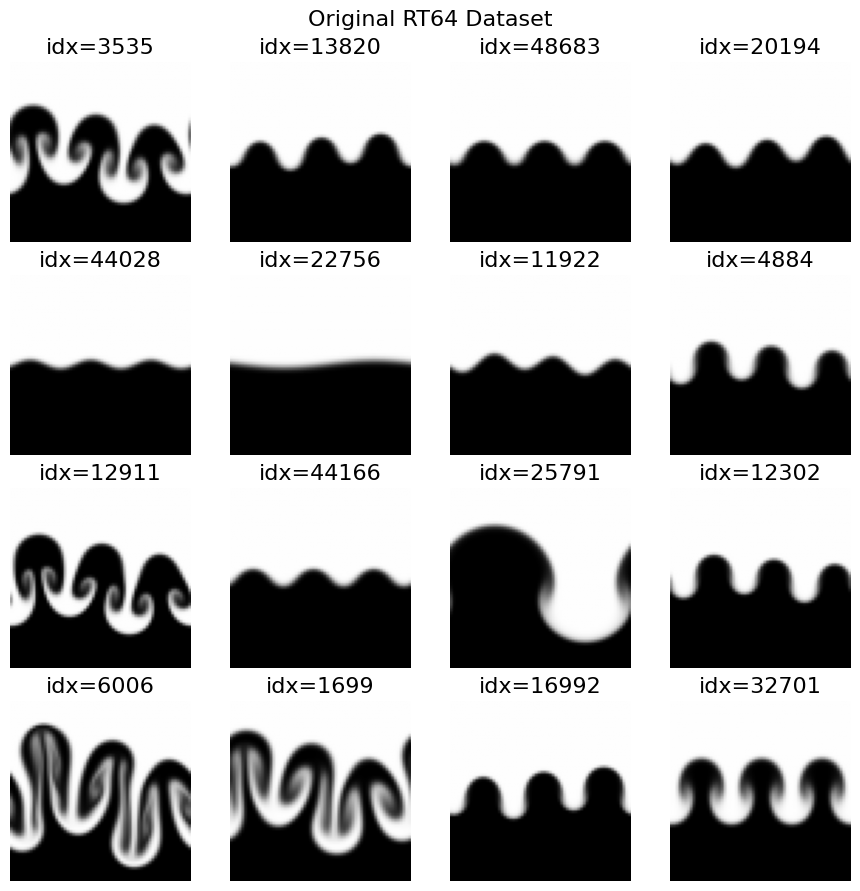

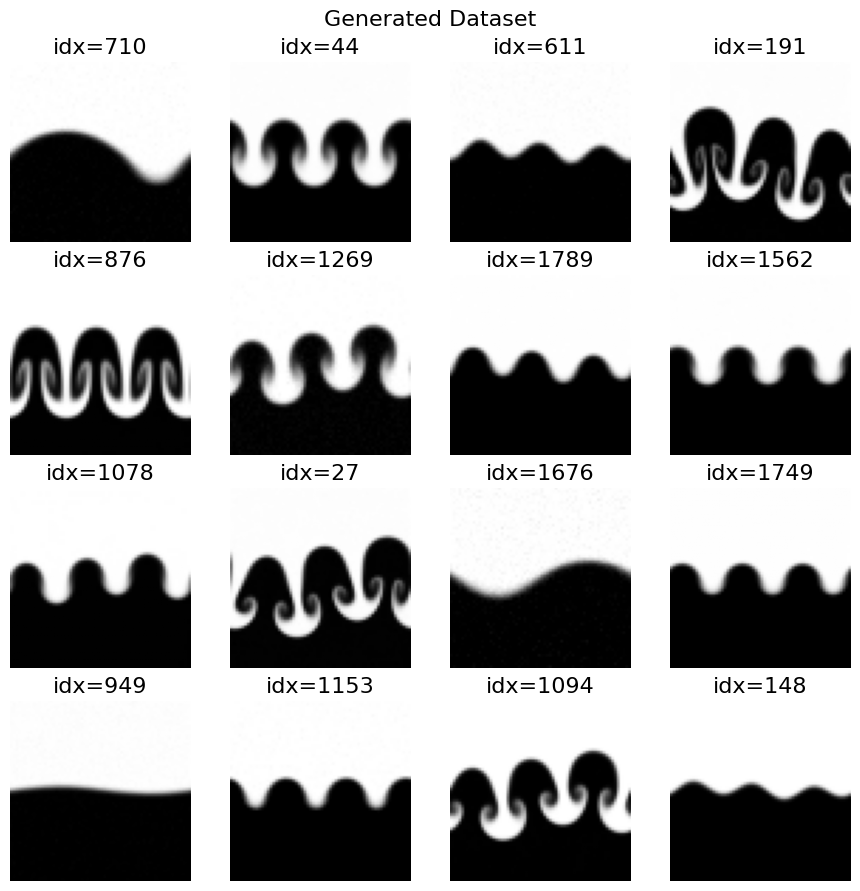

In [6]:
show_grid(train_images, n=16, cols=4, save=True,cmap=CMAP, seed=20, save_path="original.png", title="Original RT64 Dataset", colorbar=False)
show_grid(generated_dataset, n=16, cols=4, save=True, cmap=CMAP, seed=16, save_path="generated.png", title="Generated Dataset", colorbar=False)


---
## Training Information


In [7]:
def plot_loss_curve(csv_path, save=False, save_path="loss_curve.png"):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "train_loss" not in data.dtype.names:
        raise ValueError("The CSV must contain the 'epoch' and 'train_loss' columns.")

    epochs = data["epoch"]
    train_loss = data["train_loss"]
    val_loss = data["val_loss"] if "val_loss" in data.dtype.names else None
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, train_loss, label="train_loss")
    if val_loss is not None:
        ax[0].plot(epochs, val_loss, label="val_loss", alpha=0.8)
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(train_loss, eps, None)), label="log(train_loss)")
    if val_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(val_loss, eps, None)), label="log(val_loss)", alpha=0.8)
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()

    if save:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


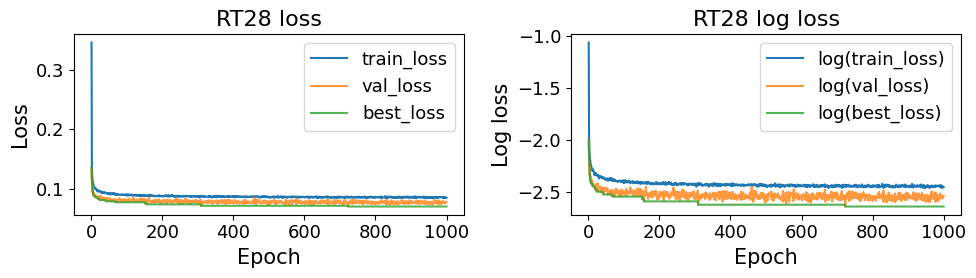

In [8]:
plot_loss_curve(LOSS_CSV, save=False, save_path="loss_curve.png")

---
# Metrics

Metrics used to compare the generated data with the original data.

## FID

FID (*Frechet Inception Distance*) compares two image datasets after projection into a feature space. We denote the feature extractor by $\phi$, for example InceptionV3 for classical FID or the learned encoder in the PhyFID case. For a reference dataset $\rho = \{\rho_i\}_{i=1}^{n}$ and a generated dataset $\varrho = \{\varrho_i\}_{i=1}^{m}$, we therefore work with
$$ \tilde{\rho}_i = \phi(\rho_i) \in \mathbb{R}^d, \qquad \tilde{\varrho}_i = \phi(\varrho_i) \in \mathbb{R}^d. $$

As with PCA in the comparison notebook, the dataset is summarized in a latent space by its mean and covariance. For the reference dataset:
$$ \mu_{\rho} = \frac{1}{n}\sum_{i=1}^{n} \tilde{\rho}_i, \qquad
\Sigma_{\rho} = \frac{1}{n-1}\sum_{i=1}^{n}(\tilde{\rho}_i-\mu_{\rho})(\tilde{\rho}_i-\mu_{\rho})^T. $$
We define $\mu_{\varrho}$ and $\Sigma_{\varrho}$ analogously for the generated images.

The FID assumption is that the features of each dataset can be approximated by a multivariate Gaussian distribution,
$$ \tilde{\rho} \sim \mathcal{N}(\mu_{\rho}, \Sigma_{\rho}), \qquad \tilde{\varrho} \sim \mathcal{N}(\mu_{\varrho}, \Sigma_{\varrho}). $$
The score is then the Frechet/Wasserstein-2 distance between these two Gaussian distributions:
$$ \mathrm{FID}(\rho,\varrho) = \|\mu_{\rho}-\mu_{\varrho}\|_2^2 + \mathrm{Tr}\left(\Sigma_{\rho} + \Sigma_{\varrho} - 2(\Sigma_{\rho}\Sigma_{\varrho})^{1/2}\right). $$

Intuitively, the first term measures the offset between the centers of the two feature clouds, while the covariance term measures the difference between their dispersions and correlations. A low score therefore means that the two datasets are statistically close in the space chosen by $\phi$.

In this notebook, two choices of $\phi$ are tested:
- **PhyFID**: $\phi$ is an encoder trained on RT simulations, so the comparison space is adapted to the physical dataset.
- **Inception FID**: $\phi$ is InceptionV3 pretrained on natural images, which gives a standard baseline but is not necessarily optimal for 2D physical fields.

Normalization is critical: $\phi$ compares not only visible shapes, but also the numerical values supplied to the network. Both datasets must therefore be converted to the same convention before feature extraction.

### PhyFID

PhyFID learns an encoder on `TRAIN_PT`, saves this encoder, and then compares datasets in the learned feature space. In this notebook, the encoder and reference statistics are simply reloaded from `out/` to avoid rerunning training.

In [9]:
PHYFID_N_IMAGES = min(1000, len(val_images) // 2, len(train_images), len(generated_dataset), len(noise_dataset), len(mnist_dataset))
phyfid_reference = val_images[:PHYFID_N_IMAGES]

phyfid_datasets = {
    "val vs val": val_images[PHYFID_N_IMAGES:2 * PHYFID_N_IMAGES],
    "val vs train": train_images[:PHYFID_N_IMAGES],
    "val vs generated": generated_dataset[:PHYFID_N_IMAGES],
    "val vs noise": noise_dataset[:PHYFID_N_IMAGES],
    "val vs MNIST": mnist_dataset[:PHYFID_N_IMAGES],
}

phyfid_scores = {
    name: compare_datasets(phyfid_reference, dataset, PHYFID_ENCODER, batch_size=PHYFID_BATCH_SIZE)
    for name, dataset in phyfid_datasets.items()
}

print(f"PhyFID comparison on {PHYFID_N_IMAGES} images")
for name, score in phyfid_scores.items():
    print(f"{name:<18} {score:>10.4f}")


PhyFID comparison on 1000 images
val vs val             0.6672
val vs train           0.2221
val vs generated       0.5807
val vs noise           5.3714
val vs MNIST           4.3910


### Standard Inception FID

This baseline directly uses the pretrained InceptionV3 from the local `lib/pytorch-fid-master` repository. The grayscale RT maps are repeated over three channels. Because the generated datasets contain only 1000 images here, the 64-feature block is used to limit singular-covariance issues; standard 2048-feature FID generally requires several thousand images. These scores are mainly used to compare the relative ordering of the datasets.

In [10]:
# def prepare_images_for_fid(images):
#     """Converts NHW/NCHW/NHWC to RGB NCHW in [0, 1]."""
#     original_dtype = torch.as_tensor(images).dtype
#     images = torch.as_tensor(images).detach().cpu().float()

#     if images.ndim == 3:
#         images = images.unsqueeze(1)
#     elif images.ndim == 4 and images.shape[-1] in (1, 3) and images.shape[1] not in (1, 3):
#         images = images.permute(0, 3, 1, 2)
#     if images.ndim != 4:
#         raise ValueError(f"Unsupported format: {tuple(images.shape)}")

#     if original_dtype == torch.uint8 or (images.min() >= 0 and images.max() > 1):
#         images = images / 255.0
#     elif images.min() < 0:
#         images = (images + 1.0) / 2.0

#     images = images.clamp(0.0, 1.0)
#     if images.shape[1] == 1:
#         images = images.repeat(1, 3, 1, 1)
#     if images.shape[1] != 3:
#         raise ValueError(f"FID expects 1 or 3 channels, got: {images.shape[1]}")
#     return images


# def extract_fid_features(images, model, batch_size, device):
#     images = prepare_images_for_fid(images)
#     loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)
#     features = []

#     model.eval()
#     with torch.no_grad():
#         for (batch,) in loader:
#             prediction = model(batch.to(device))[0]
#             if prediction.shape[-2:] != (1, 1):
#                 prediction = adaptive_avg_pool2d(prediction, output_size=(1, 1))
#             features.append(prediction.flatten(1).cpu().numpy())

#     return np.concatenate(features, axis=0)


# def fid_from_features(reference_features, compared_features):
#     reference_mu = np.mean(reference_features, axis=0)
#     reference_sigma = np.cov(reference_features, rowvar=False)
#     compared_mu = np.mean(compared_features, axis=0)
#     compared_sigma = np.cov(compared_features, rowvar=False)
#     return float(pytorch_fid_distance(reference_mu, reference_sigma, compared_mu, compared_sigma))


In [11]:
# FID_N_IMAGES = PHYFID_N_IMAGES
# fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[FID_DIMS]
# fid_model = InceptionV3([fid_block]).to(FID_DEVICE)

# val_reference_features = extract_fid_features(val_images[:FID_N_IMAGES], fid_model, FID_BATCH_SIZE, FID_DEVICE)

# datasets_for_fid = {
#     "val vs val": val_images[FID_N_IMAGES:2 * FID_N_IMAGES],
#     "val vs train": train_images[:FID_N_IMAGES],
#     "val vs generated": generated_dataset[:FID_N_IMAGES],
#     "val vs noise": noise_dataset[:FID_N_IMAGES],
#     "val vs MNIST": mnist_dataset[:FID_N_IMAGES],
# }

# fid_scores = {}
# for name, dataset in datasets_for_fid.items():
#     compared_features = extract_fid_features(dataset, fid_model, FID_BATCH_SIZE, FID_DEVICE)
#     fid_scores[name] = fid_from_features(val_reference_features, compared_features)

# print(f"Comparison on {FID_N_IMAGES} images (Inception: {FID_DIMS} features)")
# print(f"{'Comparison':<18} {'PhyFID':>12} {'FID Inception':>16}")
# for name in datasets_for_fid:
#     print(f"{name:<18} {phyfid_scores[name]:>12.4f} {fid_scores[name]:>16.4f}")

# del fid_model
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()


---
## Physical Metric

This section gathers the physical metrics built directly on the fields $\rho(t,x,y)$. It is organized into four blocks:
- tensor preparation and normalization ;
- mean-density statistics by row ;
- visualization with skew-normal laws ;
- spectral energy of row-wise fluctuations.


In [12]:
from scipy.stats import skewnorm


def to_txy(tensor):
    """Converts an image tensor to canonical shape ``(t, x, y)``.

    Args:
        tensor (torch.Tensor | np.ndarray): Input data with shape ``(t, x, y)``
            or ``(t, 1, x, y)``.

    Returns:
        torch.Tensor: Floating-point tensor with shape ``(t, x, y)``.

    Raises:
        ValueError: If the data cannot be interpreted as a time-indexed 2D field.
    """
    tensor = torch.as_tensor(tensor).float()
    if tensor.ndim == 4 and tensor.shape[1] == 1:
        tensor = tensor[:, 0]
    if tensor.ndim != 3:
        raise ValueError(f"Expected tensor in (t, x, y) or (t, 1, x, y), got {tuple(tensor.shape)}")
    return tensor


def normalize_01(tensor, normalize=True):
    """Normalizes fields in the ``[0, 1]`` convention.

    Args:
        tensor (torch.Tensor | np.ndarray): Data with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.
        normalize (bool, optional): If ``True``, divides by 255 when the values
            appear to be in the ``[0, 255]`` convention. Defaults to True.

    Returns:
        torch.Tensor: Floating-point data with shape ``(t, x, y)``.
    """
    tensor = to_txy(tensor)
    if normalize and tensor.max() > 1.5:
        tensor = tensor / 255.0
    return tensor


def fit_skewnorm_1d(values, min_scale=1e-6, max_abs_alpha=50):
    """Fits a skew-normal distribution to a 1D vector.

    Args:
        values (array-like): 1D samples to fit.
        min_scale (float, optional): Minimum allowed width to avoid a
            numerically singular density. Defaults to 1e-6.
        max_abs_alpha (float, optional): Maximum absolute value of the returned
            skewness parameter. Defaults to 50.

    Returns:
        tuple[float, float, float]: ``(alpha, loc, scale)`` parameters of
            ``scipy.stats.skewnorm``.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 0.0, 0.0, min_scale

    mean = float(np.mean(values))
    std = float(np.std(values))
    if values.size < 3 or std < min_scale:
        return 0.0, mean, max(std, min_scale)

    try:
        alpha, loc, scale = skewnorm.fit(values)
        if not np.isfinite([alpha, loc, scale]).all() or scale < min_scale:
            raise ValueError("Invalid skew-normal parameters")
        alpha = float(np.clip(alpha, -max_abs_alpha, max_abs_alpha))
        return alpha, float(loc), float(scale)
    except Exception:
        return 0.0, mean, max(std, min_scale)


def fit_skewnorm_layers(layer_values):
    """Fits a skew-normal distribution for each spatial row.

    Args:
        layer_values (array-like): Array with shape ``(t, x)`` containing a row
            statistic for each time and each row.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: ``alpha``, ``loc``, and
            ``scale`` arrays with shape ``(x,)``.
    """
    layer_values = np.asarray(layer_values, dtype=float)
    params = np.array([fit_skewnorm_1d(layer_values[:, i]) for i in range(layer_values.shape[1])])
    return params[:, 0], params[:, 1], params[:, 2]


In [13]:
val_stats = normalize_01(val_images)
generated_stats = normalize_01(generated_dataset)
mnist_stats = normalize_01(mnist_dataset)
noise_stats = normalize_01(noise_dataset)

### Mean-Density Statistics by Row

Here we compare the physical fields row by row. We denote the validation dataset by $\rho(t,x,y)$ and a compared dataset by $\varrho(t,x,y)$, where $t$ indexes images, $x$ rows, and $y$ columns. The objective is to reduce each row to a 1D quantity while preserving the structure along $x$.

For each time $t$ and each row $x$, we first compute the mean over $y$:
$$ m_{\rho}(t,x) = \frac{1}{N_y}\sum_{y=1}^{N_y} \rho(t,x,y), \qquad
m_{\varrho}(t,x) = \frac{1}{N_y}\sum_{y=1}^{N_y} \varrho(t,x,y). $$

Each row is then summarized by its temporal mean:
$$ \tilde{\rho}_l(x) = \frac{1}{N_t}\sum_{t=1}^{N_t} m_{\rho}(t,x), \qquad
\tilde{\varrho}_l(x) = \frac{1}{N_t}\sum_{t=1}^{N_t} m_{\varrho}(t,x). $$

The temporal dispersion of row means is defined by:
$$ \sigma_{\rho,l}(x) = \sqrt{\frac{1}{N_t}\sum_{t=1}^{N_t}\left(m_{\rho}(t,x)-\tilde{\rho}_l(x)\right)^2}, \qquad
\sigma_{\varrho,l}(x) = \sqrt{\frac{1}{N_t}\sum_{t=1}^{N_t}\left(m_{\varrho}(t,x)-\tilde{\varrho}_l(x)\right)^2}. $$

In other words, the fluctuation of a row around its mean profile is
$$ \delta m_{\rho}(t,x) = m_{\rho}(t,x)-\tilde{\rho}_l(x), $$
and the temporal variance corresponds to the mean square of this fluctuation:
$$ \sigma_{\rho,l}^2(x) = \overline{\delta m_{\rho}^2}(x). $$
The standard deviation $\sigma_{\rho,l}(x)$ is therefore the typical amplitude of the temporal fluctuations of row $x$.

The distances used in `line_metric` then compare the profiles along $x$:
$$ d_{\mu}(\rho,\varrho) = \frac{1}{N_x}\left\|\tilde{\rho}_l-\tilde{\varrho}_l\right\|_2, \qquad
d_{\sigma}(\rho,\varrho) = \frac{1}{N_x}\left\|\sigma_{\rho,l}-\sigma_{\varrho,l}\right\|_2. $$

Finally, to visualize the temporal distribution of each row, a skew-normal distribution is fitted to each vector $m_{\rho}(:,x)$:
$$ m_{\rho}(:,x) \sim \mathrm{SN}\left(\alpha_{\rho,l}(x), \xi_{\rho,l}(x), \omega_{\rho,l}(x)\right), $$
and similarly for $m_{\varrho}(:,x)$. The joyplots display these fitted distributions row by row, making both center shifts and distribution skewness visible.

In [14]:
def as_txy_numpy(data):
    """Converts image fields to an ``ndarray`` with shape ``(t, x, y)``.

    Args:
        data (torch.Tensor | np.ndarray): Data with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.

    Returns:
        np.ndarray: Floating-point data with shape ``(t, x, y)``.

    Raises:
        ValueError: If the data shape is not supported.
    """
    if torch.is_tensor(data):
        data = data.detach().cpu().numpy()
    data = np.asarray(data, dtype=float)
    if data.ndim == 4 and data.shape[1] == 1:
        data = data[:, 0]
    if data.ndim != 3:
        raise ValueError(f"Expected data in (t, x, y) or (t, 1, x, y), got {data.shape}")
    return data


def line_metric(validation, generated, metric_name="mu"):
    """Compares two field datasets using row profiles.

    Args:
        validation (torch.Tensor | np.ndarray): Reference dataset with shape
            ``(t, x, y)`` or ``(t, 1, x, y)``.
        generated (torch.Tensor | np.ndarray): Compared dataset with shape
            ``(t, x, y)`` or ``(t, 1, x, y)``.
        metric_name (str, optional): Compared profile type. ``"mu"`` compares
            the temporal mean of ``mean_y``; ``"sigma"`` compares its temporal
            standard deviation. Defaults to "mu".

    Returns:
        tuple[float, np.ndarray, np.ndarray]: Normalized distance, profile of
            the compared dataset, and profile of the validation dataset.

    Raises:
        ValueError: If the two datasets do not have the same number of rows or
            if ``metric_name`` is not supported.
    """
    validation = as_txy_numpy(validation)
    generated = as_txy_numpy(generated)
    if validation.shape[1] != generated.shape[1]:
        raise ValueError(f"The number of x rows must be the same for validation and generated: {validation.shape[1]} vs {generated.shape[1]}")

    n_x = validation.shape[1]
    mu_val = validation.mean(axis=2)
    mu_gen = generated.mean(axis=2)
    if metric_name == "mu":
        MU_l_val = np.mean(mu_val, axis=0)
        MU_l_gen = np.mean(mu_gen, axis=0)
        distance = np.linalg.norm(MU_l_val - MU_l_gen) / n_x
        return distance, MU_l_gen, MU_l_val 
    elif metric_name == "sigma":
        SIGMA_l_val = np.std(mu_val, axis=0)
        SIGMA_l_gen = np.std(mu_gen, axis=0)
        distance = np.linalg.norm(SIGMA_l_val - SIGMA_l_gen) / n_x
        return distance, SIGMA_l_gen, SIGMA_l_val
    else:
        raise ValueError(f"Unsupported metric: {metric_name}")
    

def get_alpha(data):
    """Fits a skew-normal distribution to the row means of a dataset.

    Args:
        data (torch.Tensor | np.ndarray): Data with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray]: ``alpha``, ``loc``, and
            ``scale`` arrays with shape ``(x,)``.
    """
    data = as_txy_numpy(data)
    d = data.mean(axis=2)
    ALPHA_l_val, LOC_l_val, SCALE_l_val = fit_skewnorm_layers(d)
    return ALPHA_l_val, LOC_l_val, SCALE_l_val


### Visualization with skew-normal joyplots

The following functions display the skew-normal laws fitted to the temporal distributions of each row. The curves are height-normalized to make center shifts and skewness easier to read.


In [15]:
def skewnorm_pdf(x, alpha, loc, scale):
    """Evaluates the density of a skew-normal distribution.

    Args:
        x (np.ndarray): Points at which to evaluate the density.
        alpha (float): Skewness parameter.
        loc (float): Location parameter.
        scale (float): Scale parameter.

    Returns:
        np.ndarray: Density values at points ``x``.
    """
    scale = float(scale)
    if scale <= 0:
        return np.zeros_like(x)
    return skewnorm.pdf(x, float(alpha), loc=float(loc), scale=scale)


def plot_skewnorm_joyplot(n_curves, alpha1, loc1, scale1, alpha2=None, loc2=None, scale2=None, *, ax=None, title="", label1="Validation", label2="Generated", color1="tab:blue", color2="tab:orange", x_min=-0.05, x_max=1.05):
    """Plots a row-wise joyplot of skew-normal distributions.

    Args:
        n_curves (int): Number of rows to display between the top and bottom
            boundaries of the field.
        alpha1 (array-like): Skewness parameters of the first dataset, shape ``(x,)``.
        loc1 (array-like): Location parameters of the first dataset, shape ``(x,)``.
        scale1 (array-like): Scale parameters of the first dataset, shape ``(x,)``.
        alpha2 (array-like, optional): Skewness parameters of the second dataset.
            Defaults to None.
        loc2 (array-like, optional): Location parameters of the second dataset.
            Defaults to None.
        scale2 (array-like, optional): Scale parameters of the second dataset.
            Defaults to None.
        ax (matplotlib.axes.Axes, optional): Axes on which to plot. Defaults to None.
        title (str, optional): Subplot title. Defaults to "".
        label1 (str, optional): Label of the first dataset. Defaults to "Validation".
        label2 (str, optional): Label of the second dataset. Defaults to "Generated".
        color1 (str, optional): Color of the first dataset. Defaults to "tab:blue".
        color2 (str, optional): Color of the second dataset. Defaults to "tab:orange".
        x_min (float, optional): Lower bound of the horizontal axis. Defaults to -0.05.
        x_max (float, optional): Upper bound of the horizontal axis. Defaults to 1.05.

    Returns:
        matplotlib.axes.Axes: Axes containing the joyplot.

    Raises:
        ValueError: If the parameter arrays have incompatible shapes.
    """
    alpha1 = np.asarray(alpha1)
    loc1 = np.asarray(loc1)
    scale1 = np.asarray(scale1)
    if alpha1.shape != loc1.shape or loc1.shape != scale1.shape:
        raise ValueError("alpha1, loc1, and scale1 must have the same shape")

    has_second = alpha2 is not None and loc2 is not None and scale2 is not None
    if has_second:
        alpha2 = np.asarray(alpha2)
        loc2 = np.asarray(loc2)
        scale2 = np.asarray(scale2)
        if alpha2.shape != loc2.shape or loc2.shape != scale2.shape or loc2.shape != loc1.shape:
            raise ValueError("alpha2/loc2/scale2 must have the same shape as alpha1/loc1/scale1")

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3.5))

    n_curves = min(int(n_curves), len(loc1))
    selected_idx = np.linspace(0, len(loc1) - 1, n_curves, dtype=int)
    x = np.linspace(x_min, x_max, 800)
    spacing = 1.0
    height = 0.55

    for plot_idx, layer_idx in enumerate(selected_idx):
        offset = plot_idx * spacing

        y1 = skewnorm_pdf(x, alpha1[layer_idx], loc1[layer_idx], scale1[layer_idx])
        y1 = y1 / y1.max() * height if y1.max() > 0 else y1
        ax.fill_between(x, offset, offset + y1, color=color1, alpha=0.35)
        ax.plot(x, offset + y1, color=color1, linewidth=1.2, label=label1 if plot_idx == 0 else None)
        ax.axvline(loc1[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color1, linestyle="--", linewidth=0.8, alpha=0.7)

        if has_second:
            y2 = skewnorm_pdf(x, alpha2[layer_idx], loc2[layer_idx], scale2[layer_idx])
            y2 = y2 / y2.max() * height if y2.max() > 0 else y2
            ax.fill_between(x, offset, offset + y2, color=color2, alpha=0.30)
            ax.plot(x, offset + y2, color=color2, linewidth=1.2, label=label2 if plot_idx == 0 else None)
            ax.axvline(loc2[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color2, linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(np.arange(n_curves) * spacing)
    ax.set_yticklabels([f"x={i}" for i in selected_idx])
    ax.set_xlabel(r"$\mu_l$")
    ax.set_ylabel("Row index")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    if has_second:
        ax.legend(loc="upper right")
    return ax


In [16]:
mu_l_dist_gen, mu_l_gen, mu_l_val = line_metric(val_stats, generated_stats, metric_name="mu")
mu_l_dist_noise, mu_l_noise, _ = line_metric(val_stats, noise_stats, metric_name="mu")
mu_l_dist_mnist, mu_l_mnist, _ = line_metric(val_stats, mnist_stats, metric_name="mu")

sigma_l_dist_gen, sigma_l_gen, sigma_l_val = line_metric(val_stats, generated_stats, metric_name="sigma")
sigma_l_dist_noise, sigma_l_noise, _ = line_metric(val_stats, noise_stats, metric_name="sigma")
sigma_l_dist_mnist, sigma_l_mnist, _ = line_metric(val_stats, mnist_stats, metric_name="sigma")

alpha_l_val, loc_l_val, scale_l_val = get_alpha(val_stats)
alpha_l_generated, loc_l_generated, scale_l_generated = get_alpha(generated_stats)
alpha_l_mnist, loc_l_mnist, scale_l_mnist = get_alpha(mnist_stats)
alpha_l_noise, loc_l_noise, scale_l_noise = get_alpha(noise_stats)

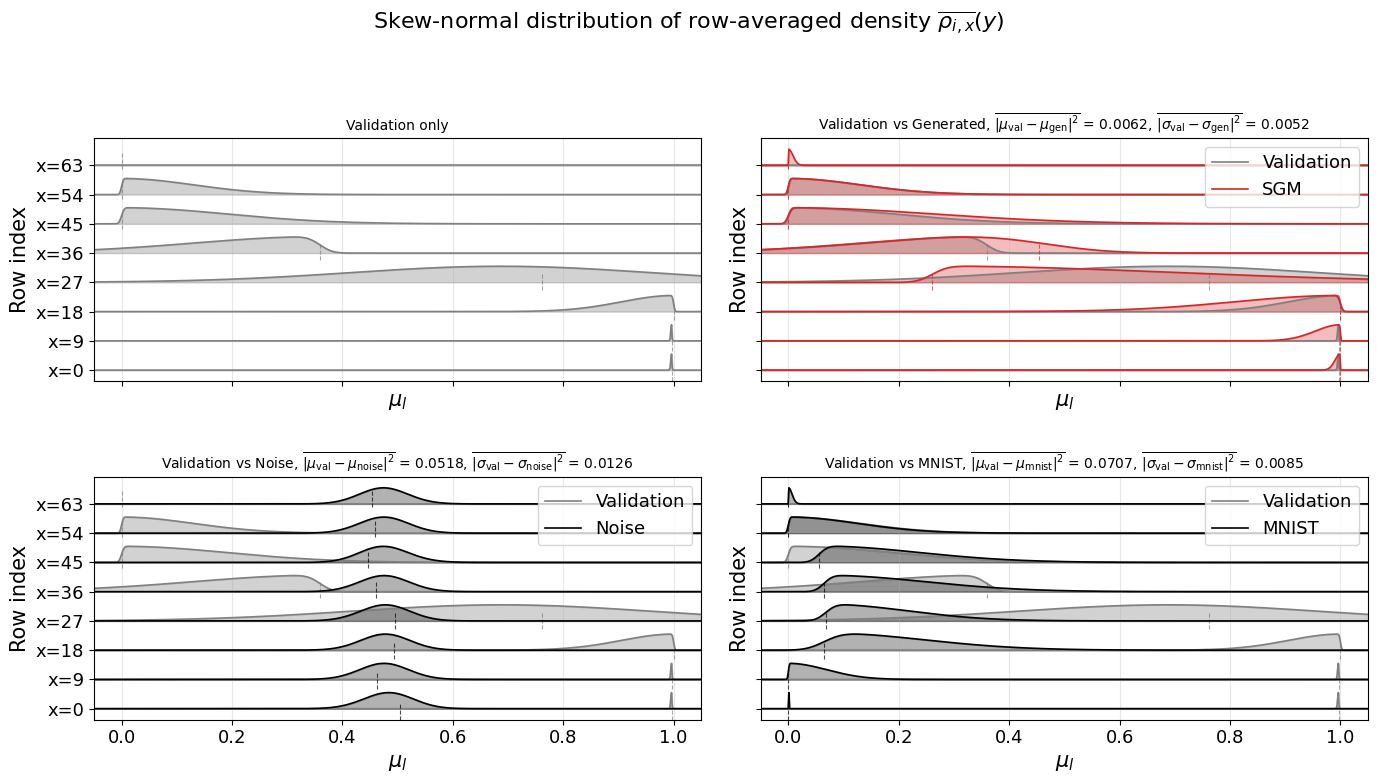

In [44]:
title_2 = (
    "Validation vs Generated, "
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{gen}}|^2}$"
    f" = {mu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{gen}}|^2}$"
    f" = {sigma_l_dist_gen:.4f}"
)
title_3 = (
    "Validation vs Noise, "
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{noise}}|^2}$"
    f" = {mu_l_dist_noise:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{noise}}|^2}$"
    f" = {sigma_l_dist_noise:.4f}"
)
title_4 = (
    "Validation vs MNIST, "
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{mnist}}|^2}$"
    f" = {mu_l_dist_mnist:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{mnist}}|^2}$"
    f" = {sigma_l_dist_mnist:.4f}"
)

n_curves = 8
subplot_title_fontsize = 10
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
color1 = "gray"

plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, ax=axes[0, 0], title="Validation only", color1=color1)
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_generated, loc_l_generated, scale_l_generated, ax=axes[0, 1], title=title_2, label2="SGM",color1=color1, color2="#d62728")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_noise, loc_l_noise, scale_l_noise, ax=axes[1, 0], title=title_3, label2="Noise", color1=color1, color2="black")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_mnist, loc_l_mnist, scale_l_mnist, ax=axes[1, 1], title=title_4, label2="MNIST", color1=color1, color2="black")

for ax in axes.ravel():
    ax.title.set_fontsize(subplot_title_fontsize)

fig.suptitle(r"Skew-normal distribution of row-averaged density $\overline{\rho_{i,x}}(y)$", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0, w_pad=1.5)
plt.savefig("../doc/BDRPReportTemplate/figures/ch4/skewnorm_joyplot.png", bbox_inches="tight", dpi=300)
plt.show()

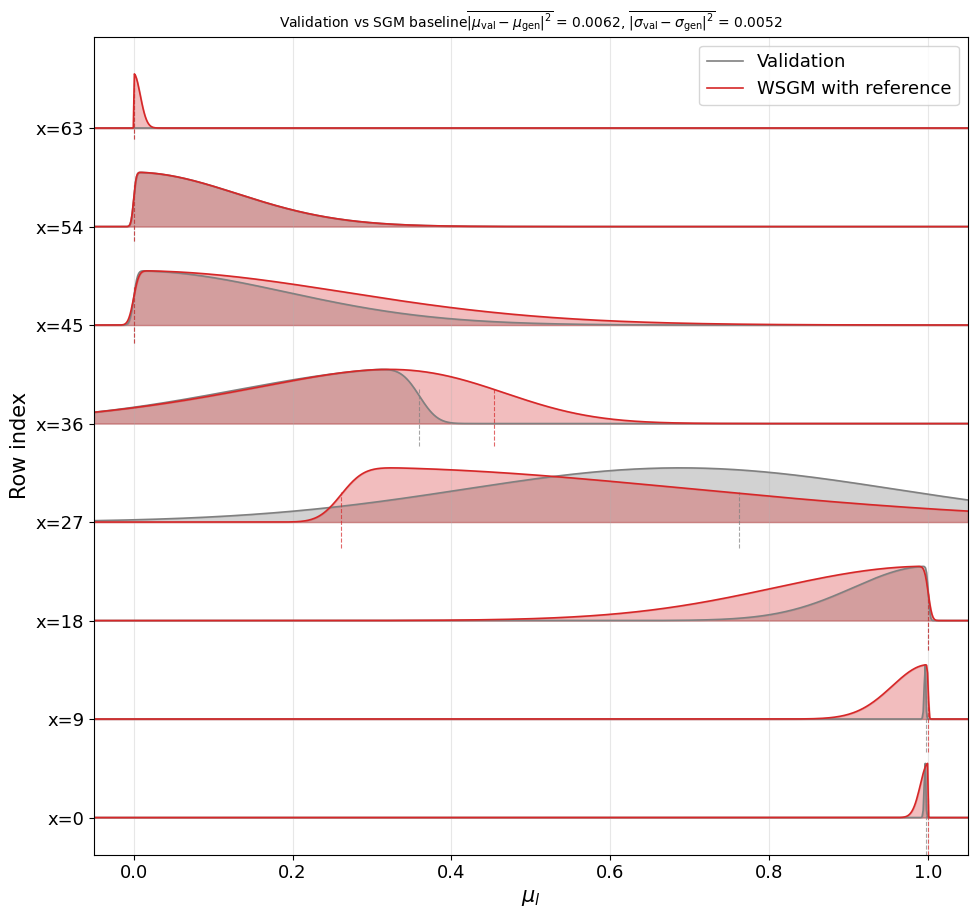

In [47]:
title_2 = (
    "Validation vs SGM baseline"
    r"$\overline{|\mu_{\mathrm{val}} - \mu_{\mathrm{gen}}|^2}$"
    f" = {mu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{gen}}|^2}$"
    f" = {sigma_l_dist_gen:.4f}"
)

n_curves = 8
subplot_title_fontsize = 10
fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharex=True, sharey=True)
color1 = "gray"

plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_generated, loc_l_generated, scale_l_generated, ax=ax, title=title_2, label2="WSGM with reference", color1=color1, color2="#d62728")
ax.title.set_fontsize(subplot_title_fontsize)

# fig.suptitle(r"Skew-normal distribution of row-averaged density $\overline{\rho_{i,x}}(y)$", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0, w_pad=1.5)
plt.savefig("../doc/BDRPReportTemplate/figures/ch5/SGM_baseline_joyplot.png", bbox_inches="tight", dpi=300)
plt.show()

### Spectral Energy of Row-Wise Fluctuations

Here we apply the same row-wise comparison logic, but to a spectral representation of the fluctuations. For a field $\rho(t,x,y)$, we first define the global fluctuation:
$$ \delta\rho(t,x,y) = \left|\rho(t,x,y)-\langle\rho\rangle_{t,x,y}\right|. $$

We then compute its Fourier transform. When the selected axis is $x$, we use a 1D FFT:
$$ \widehat{\delta\rho}(t,k_x,y) = \mathcal{F}_x\left[\delta\rho(t,x,y)\right]. $$
For a 2D transform, we instead use:
$$ \widehat{\delta\rho}(t,k_x,k_y) = \mathcal{F}_{x,y}\left[\delta\rho(t,x,y)\right]. $$

The spectral energy is then defined as the squared modulus:
$$ E_{\rho}(t,k_x,y) = \left|\widehat{\delta\rho}(t,k_x,y)\right|^2. $$

The `line_metric` function can then be reapplied to $E_{\rho}$ and $E_{\varrho}$: the row-wise mean becomes an energy mean over the remaining axis, and the distances compare the mean spectral profiles and their temporal fluctuations.

In [18]:
def transformation_Fluctuation_Eenergy_Spectrum(data, ax):
    """Computes the fluctuation energy spectrum of a field.

    Args:
        data (torch.Tensor | np.ndarray): Field with shape ``(t, x, y)`` or
            ``(t, 1, x, y)``.
        ax (int): Fourier axis. ``-1`` applies a 2D FFT over ``(x, y)``;
            any other value applies a 1D FFT over this axis.

    Returns:
        np.ndarray: Energy spectrum ``|FFT(delta rho)|^2`` with shape
            compatible with the input converted to ``(t, x, y)``.
    """
    data = as_txy_numpy(data)
    fluctuation_val = np.abs(data - data.mean())

    if ax == -1:
        fluctuation_spectrum_val = np.fft.fftshift(np.fft.fft2(fluctuation_val, axes=(-2, -1)), axes=(-2, -1))
    else:
        fluctuation_spectrum_val = np.fft.fftshift(
            np.fft.fft(fluctuation_val, axis=ax),
            axes=ax,
        )

    energy_spectrum_val = np.abs(fluctuation_spectrum_val) ** 2
    return energy_spectrum_val


In [19]:
Smu_l_dist_gen, Smu_l_gen, Smu_l_val = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1), 
                                                   transformation_Fluctuation_Eenergy_Spectrum(generated_stats, 1), 
                                                   metric_name="mu")
Smu_l_dist_noise, Smu_l_noise, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1),
                                                transformation_Fluctuation_Eenergy_Spectrum(noise_stats, 1),
                                                metric_name="mu")
Smu_l_dist_mnist, Smu_l_mnist, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1),
                                                transformation_Fluctuation_Eenergy_Spectrum(mnist_stats, 1),
                                                metric_name="mu")

Ssigma_l_dist_gen, Ssigma_l_gen, Ssigma_l_val = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1),
                                                    transformation_Fluctuation_Eenergy_Spectrum(generated_stats, 1),
                                                    metric_name="sigma")
Ssigma_l_dist_noise, Ssigma_l_noise, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1), 
                                                     transformation_Fluctuation_Eenergy_Spectrum(noise_stats, 1), 
                                                     metric_name="sigma")
Ssigma_l_dist_mnist, Ssigma_l_mnist, _ = line_metric(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1), 
                                                     transformation_Fluctuation_Eenergy_Spectrum(mnist_stats, 1), 
                                                     metric_name="sigma")

Salpha_l_val, Sloc_l_val, Sscale_l_val = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(val_stats, 1))
Salpha_l_generated, Sloc_l_generated, Sscale_l_generated = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(generated_stats, 1))
Salpha_l_mnist, Sloc_l_mnist, Sscale_l_mnist = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(mnist_stats, 1))
Salpha_l_noise, Sloc_l_noise, Sscale_l_noise = get_alpha(transformation_Fluctuation_Eenergy_Spectrum(noise_stats, 1))

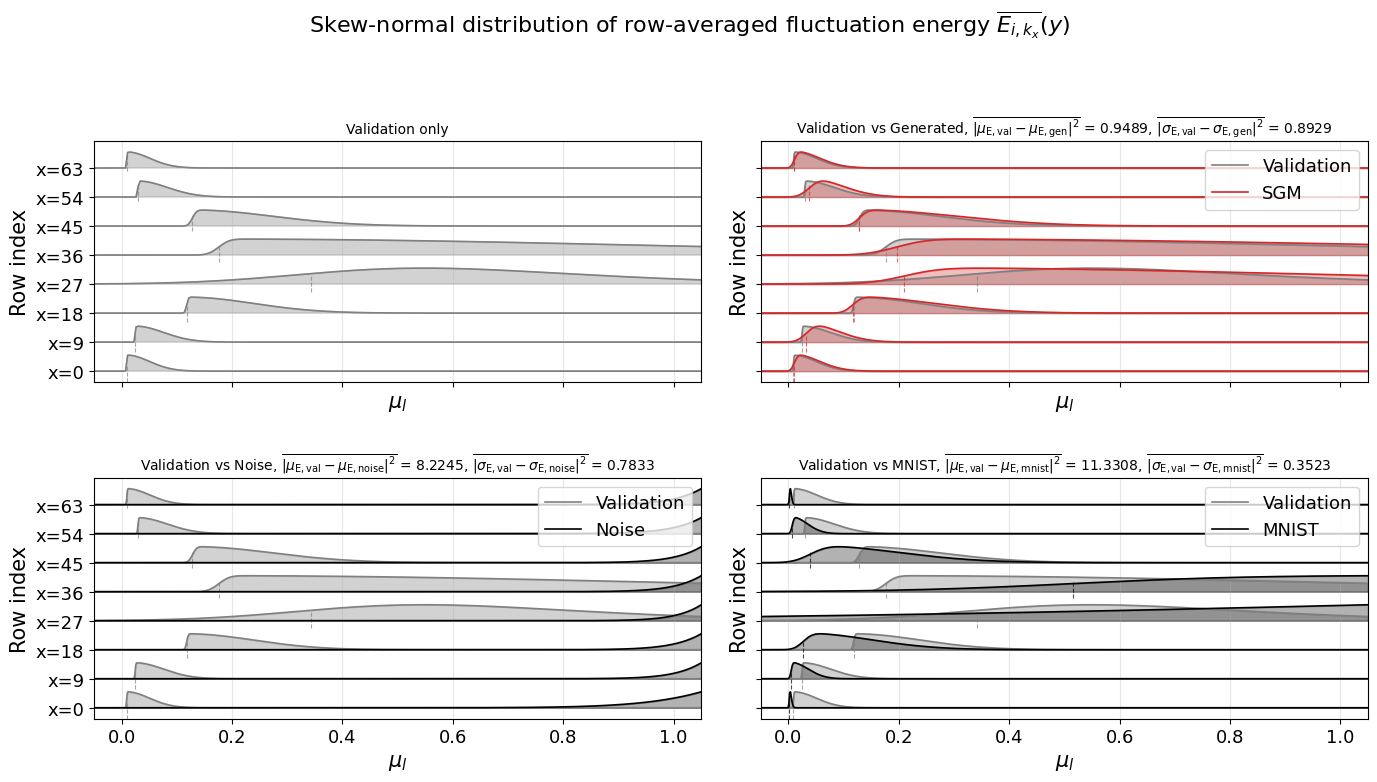

In [39]:
title_2 = (
    "Validation vs Generated, "
    r"$\overline{|\mu_{\mathrm{E,val}} - \mu_{\mathrm{E,gen}}|^2}$"
    f" = {Smu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{E,val}} - \sigma_{\mathrm{E,gen}}|^2}$"
    f" = {Ssigma_l_dist_gen:.4f}"
)
title_3 = (
    "Validation vs Noise, "
    r"$\overline{|\mu_{\mathrm{E,val}} - \mu_{\mathrm{E,noise}}|^2}$"
    f" = {Smu_l_dist_noise:.4f}, "
    r"$\overline{|\sigma_{\mathrm{E,val}} - \sigma_{\mathrm{E,noise}}|^2}$"
    f" = {Ssigma_l_dist_noise:.4f}"
)
title_4 = (
    "Validation vs MNIST, "
    r"$\overline{|\mu_{\mathrm{E,val}} - \mu_{\mathrm{E,mnist}}|^2}$"
    f" = {Smu_l_dist_mnist:.4f}, "
    r"$\overline{|\sigma_{\mathrm{E,val}} - \sigma_{\mathrm{E,mnist}}|^2}$"
    f" = {Ssigma_l_dist_mnist:.4f}"
)

n_curves = 8
subplot_title_fontsize = 10
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
color1 = "gray"

plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, ax=axes[0, 0], title="Validation only", x_max=3, label1="Validation", color1=color1)
plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, Salpha_l_generated, Sloc_l_generated, Sscale_l_generated, ax=axes[0, 1], title=title_2, label2="SGM", color1=color1, color2="#d62728")
plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, Salpha_l_noise, Sloc_l_noise, Sscale_l_noise, ax=axes[1, 0], title=title_3, label2="Noise", color1=color1, color2="black")
plot_skewnorm_joyplot(n_curves, Salpha_l_val, Sloc_l_val, Sscale_l_val, Salpha_l_mnist, Sloc_l_mnist, Sscale_l_mnist, ax=axes[1, 1], title=title_4, label2="MNIST", color1=color1, color2="black")

for ax in axes.ravel():
    ax.title.set_fontsize(subplot_title_fontsize)

fig.suptitle(r"Skew-normal distribution of row-averaged fluctuation energy $\overline{E_{i,k_x}}(y)$", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.94], h_pad=2.0, w_pad=1.5)
fig.savefig("../doc/BDRPReportTemplate/figures/ch4/skewnorm_joyplot_energy_spectrum.png", bbox_inches="tight", dpi=300)
plt.show()

---
Appendix and Additional Visualizations.

/tmp/ipykernel_11701/1023904445.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  fluctuation_val = np.abs(val_stats - val_stats.mean())


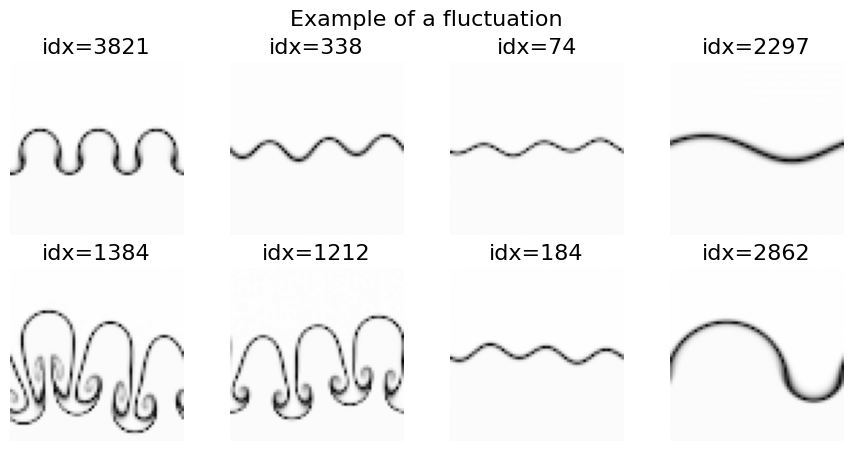

In [21]:
fluctuation_val = np.abs(val_stats - val_stats.mean())
show_grid(fluctuation_val, n=8, cols=4, save=False, save_path="fluctuation.png", title="Example of a fluctuation", colorbar=False)


/tmp/ipykernel_11701/975104414.py:6: RuntimeWarning: divide by zero encountered in log
  show_grid(abs(np.log(fluctuation_spectrum_val)), n=8, cols=4, save=False, save_path="fluctuation_spectrum.png", title="Log fluctuation spectrum", colorbar=False)


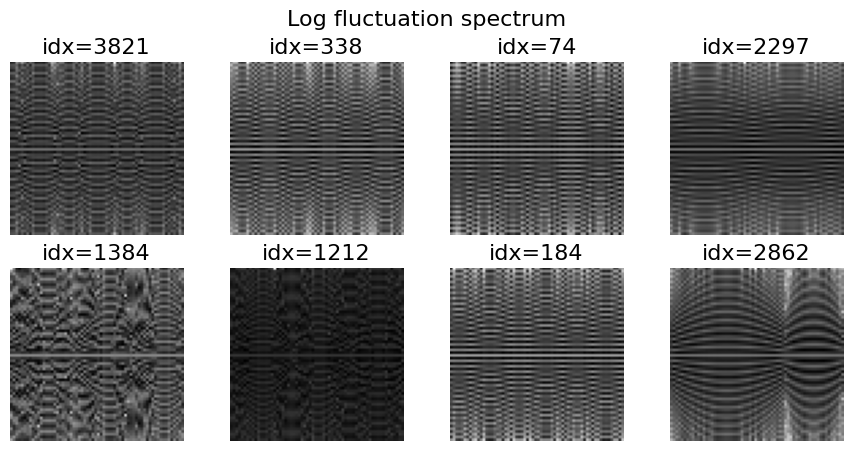

In [22]:
# fluctuation_spectrum_val = np.fft.fftshift(np.fft.fft2(fluctuation_val, axes=(-2, -1)), axes=(-2, -1))
fluctuation_spectrum_val = np.fft.fftshift(
    np.fft.fft(fluctuation_val, axis=1),
    axes=1
)
show_grid(abs(np.log(fluctuation_spectrum_val)), n=8, cols=4, save=False, save_path="fluctuation_spectrum.png", title="Log fluctuation spectrum", colorbar=False)

/tmp/ipykernel_11701/296386646.py:2: RuntimeWarning: divide by zero encountered in log
  show_grid(np.log(energy_spectrum_val), n=8, cols=4, save=False, save_path="energy_spectrum.png", title="Log fluctuation energy spectrum", colorbar=False)


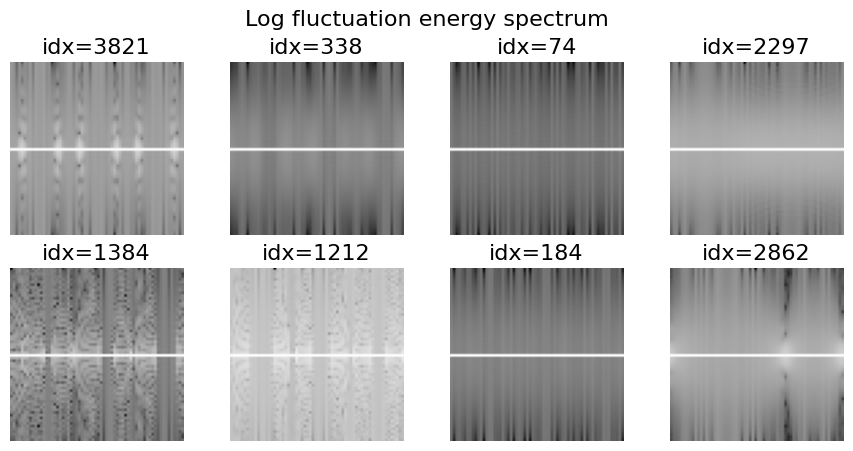

In [23]:
energy_spectrum_val = np.abs(fluctuation_spectrum_val) ** 2
show_grid(np.log(energy_spectrum_val), n=8, cols=4, save=False, save_path="energy_spectrum.png", title="Log fluctuation energy spectrum", colorbar=False)

---
## Bloc d'images générées — baseline SGM

La baseline est présentée sur un bloc fixe de 4×4 échantillons générés. Les métriques PhyFID et spectrales ci-dessus sont calculées sur le même ensemble de validation.

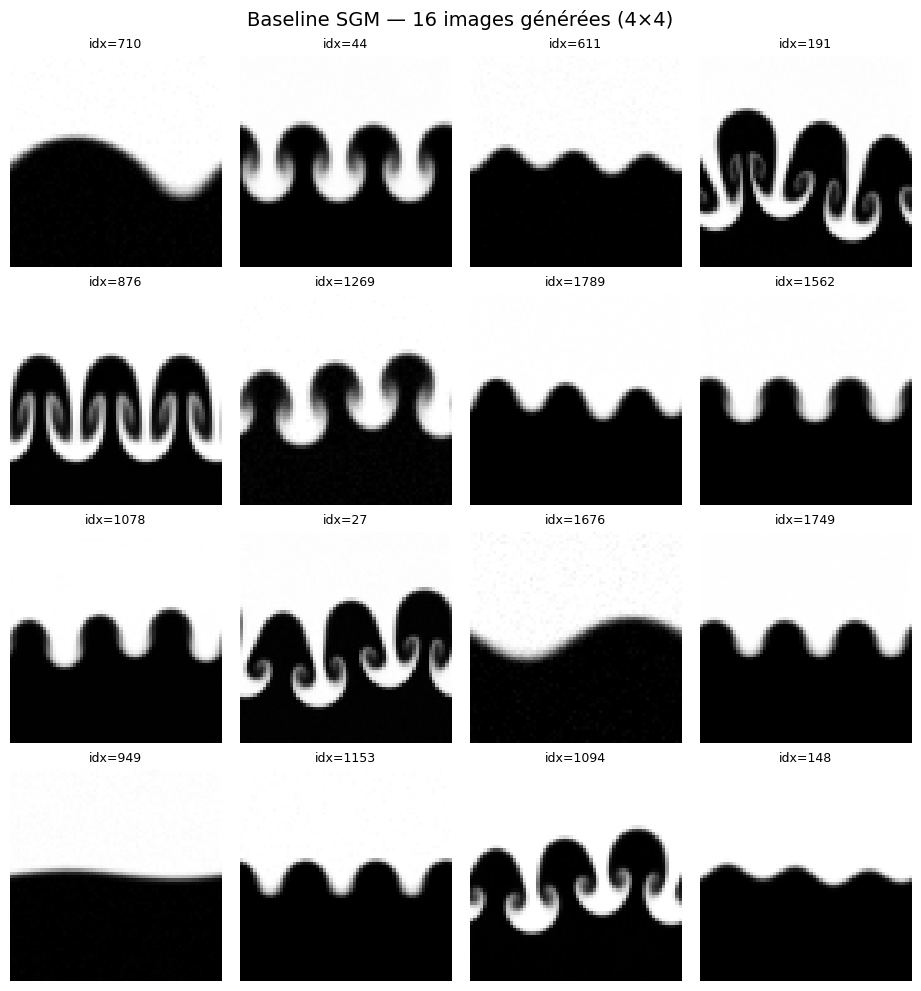

(<Figure size 920x980 with 16 Axes>,
 array([ 710,   44,  611,  191,  876, 1269, 1789, 1562, 1078,   27, 1676,
        1749,  949, 1153, 1094,  148]))

In [24]:
from result_utils import plot_image_grid
plot_image_grid(
    generated_dataset,
    n=16,
    cols=4,
    seed=16,
    cmap=CMAP,
    title="Baseline SGM — 16 images générées (4×4)",
)

## Baseline SGM — report diagnostics

The report figures below use a fixed diagnostic batch of at most 64 images. This cap applies to the row-wise skew-normal fits and to the spectra only; it prevents the diagnostic stage from exhausting memory or spending excessive time in repeated distribution fitting.


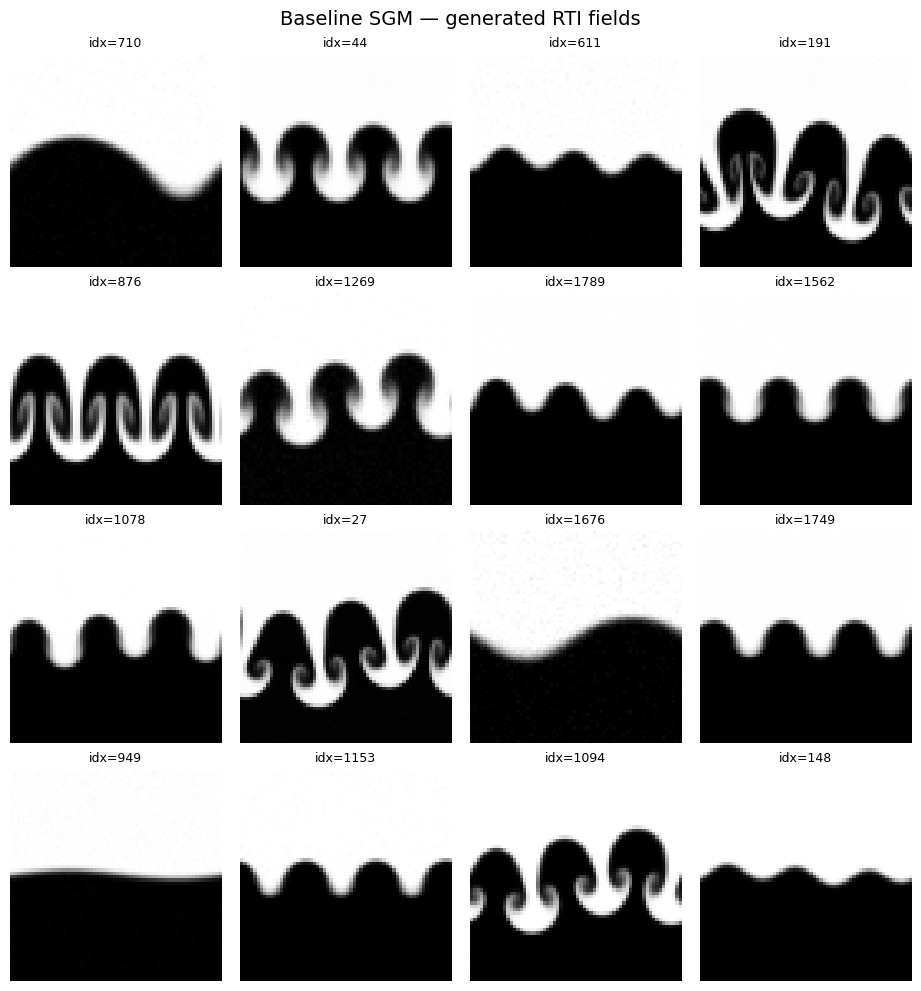

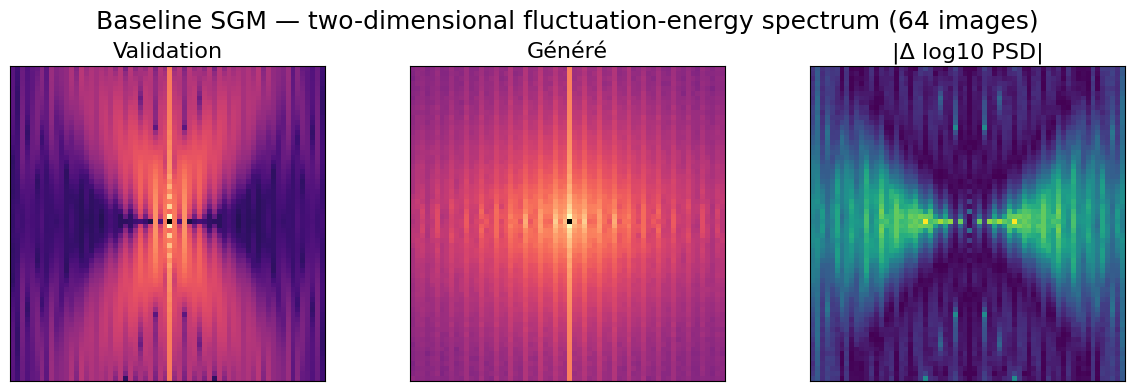

Baseline diagnostics on 64 images
Density: {'mean_distance': 0.020946190221542683, 'std_distance': 0.02009625574549415}
Fluctuation energy: {'mean_distance': 1.8874423815107737, 'std_distance': 1.7471409837990215}


In [25]:
from result_utils import (
    plot_image_grid,
    plot_skewnorm_rows,
    plot_spectral_energy,
    save_figure,
)

REPORT_FIGURE_DIR = project_root / "doc" / "BDRPReportTemplate" / "figures" / "ch5"
DIAGNOSTIC_MAX_IMAGES = 64
report_n = min(DIAGNOSTIC_MAX_IMAGES, len(val_stats), len(generated_stats))
report_reference = val_stats[:report_n]
report_generated = generated_stats[:report_n]

fig, _ = plot_image_grid(
    generated_dataset,
    n=16,
    cols=4,
    seed=16,
    cmap=CMAP,
    title="Baseline SGM — generated RTI fields",
)
save_figure(fig, REPORT_FIGURE_DIR / "baseline_sgm_grid.png")
plt.close(fig)

fig, baseline_density_metrics = plot_skewnorm_rows(
    report_reference,
    report_generated,
    quantity="density",
    n_curves=8,
    title="Baseline SGM — row-wise density statistics (64 images)",
)
save_figure(fig, REPORT_FIGURE_DIR / "baseline_sgm_skewnorm_density.png")
plt.close(fig)

fig, baseline_spectral_metrics = plot_skewnorm_rows(
    report_reference,
    report_generated,
    quantity="energy",
    n_curves=8,
    title="Baseline SGM — row-wise fluctuation-energy statistics (64 images)",
)
save_figure(fig, REPORT_FIGURE_DIR / "baseline_sgm_skewnorm_energy.png")
plt.close(fig)

fig, _ = plot_spectral_energy(
    report_reference,
    report_generated,
    title="Baseline SGM — two-dimensional fluctuation-energy spectrum (64 images)",
)
save_figure(fig, REPORT_FIGURE_DIR / "baseline_sgm_spectrum.png")
plt.close(fig)

print("Baseline diagnostics on", report_n, "images")
print("Density:", baseline_density_metrics)
print("Fluctuation energy:", baseline_spectral_metrics)
